# AT&T Spam Detector

## Introduction
As part of the **Data Science – Deep Learning certification**, we worked on a project of **automatic detection of unwanted SMS (SPAM)**.  
The objective is to build a solution capable of distinguishing normal messages (*ham*) from fraudulent or abusive promotional messages (*spam*) based on their textual content.  

## Why this project?
AT&T, one of the largest telecom operators in the United States, faces a major challenge:  
- **Users receive fraudulent or unsolicited promotional SMS messages on a daily basis.**  
- This repeated exposure to spam leads to a **loss of trust** and can result in **phishing attacks** or **financial losses**.  

The project therefore aims to provide a **robust Deep Learning solution** that automates this classification in order to **protect users** while **reducing the manual workload** of detection.  

## For whom?
- **AT&T and its technical teams**: to integrate a model into their SMS filtering systems.  
- **End users**: to benefit from better protection and a nuisance-free user experience.  
- **Data Science teams**: as a demonstration of a professional NLP approach applied to telecommunications.  

## Key project steps
1. **Exploratory Data Analysis (EDA)**  
   - Loading the SMS dataset.  
   - Analyzing class balance and ham/spam distribution.  
   - Cleaning unnecessary columns and handling missing values.  

2. **Text preprocessing and cleaning**  
   - Lowercasing, removal of noisy characters.  
   - Replacing URLs, emails, phone numbers, emojis with tokens (`[URL]`, `[NUM]`, etc.).  
   - Computing message lengths for exploratory analysis.  

3. **Train/validation/test split**  
   - Stratified split (80/10/10).  
   - Preserving ham/spam balance across datasets.  

4. **Deep Learning modeling**  
   - **LSTM with embeddings**: a simple yet effective sequential model.  
   - **BERT-tiny then BERT-small (Transfer Learning)**: comparison with a pre-trained approach.  

5. **Evaluation and optimization**  
   - Use of adapted metrics: F1, ROC-AUC, PR-AUC.  
   - Analysis of the confusion matrix.  
   - Choice of the optimal threshold (Youden, F1) according to business needs.  

6. **Error analysis**  
   - Identification of false positives (FP) and false negatives (FN).  
   - Observations on the length and type of misclassified messages.  

7. **Comparison**  
   - Visualization of LSTM vs BERT performance.  

8. **Conclusion**

In [1]:
import pandas as pd
import numpy as np
import re
import html
import emoji

## 1. Exploratory Data Analysis (EDA): structure, completeness and first insights

### Goal
Before starting NLP preprocessing and modeling, it is essential to understand the initial structure of the data.  
This step ensures that:  
- the dataset is properly loaded,  
- the columns are complete,  
- and no critical missing values are present.  

### Actions
1. **Loading the dataset** from the `spam.csv` file containing the SMS messages.  
2. **Inspecting** the structure and data types.  

In [2]:
data = pd.read_csv('spam.csv', encoding='latin-1')
data.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
data.shape

(5572, 5)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [5]:
data.isnull().sum() / len(data) * 100

v1             0.000000
v2             0.000000
Unnamed: 2    99.102656
Unnamed: 3    99.784637
Unnamed: 4    99.892319
dtype: float64

In [6]:
data[data.notna().all(axis=1)]

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
281,ham,\Wen u miss someone,the person is definitely special for u..... B...,why to miss them,"just Keep-in-touch\"" gdeve.."""
1038,ham,"Edison has rightly said, \A fool can ask more ...",GN,GE,"GNT:-)"""
2255,ham,I just lov this line: \Hurt me with the truth,I don't mind,i wil tolerat.bcs ur my someone..... But,"Never comfort me with a lie\"" gud ni8 and swe..."
3525,ham,\HEY BABE! FAR 2 SPUN-OUT 2 SPK AT DA MO... DE...,HAD A COOL NYTHO,TX 4 FONIN HON,"CALL 2MWEN IM BK FRMCLOUD 9! J X\"""""
4668,ham,"When I was born, GOD said, \Oh No! Another IDI...",GOD said,"\""OH No! COMPETITION\"". Who knew","one day these two will become FREINDS FOREVER!"""
5048,ham,"Edison has rightly said, \A fool can ask more ...",GN,GE,"GNT:-)"""


In [7]:
data = data.iloc[:, :2]
data.columns = ['type', 'text']
data.head()

,type,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
data['type'].value_counts()

type
ham     4825
spam     747
Name: count, dtype: int64

In [9]:
data['text_len'] = data['text'].apply(lambda x : len(x))
data.sample(25)

,type,text,text_len
3070,ham,Apart from the one i told you about yesterday?,46
3036,ham,Cos darren say Ì_ considering mah so i ask Ì_...,48
4308,ham,He dint tell anything. He is angry on me that ...,66
3446,ham,Sitting ard nothing to do lor. U leh busy w work?,49
5475,ham,Dhoni have luck to win some big title.so we wi...,54
5119,ham,Lol for real. She told my dad I have cancer,43
4197,spam,Want to funk up ur fone with a weekly new tone...,155
4609,ham,Just glad to be talking to you.,31
3360,ham,You only hate me. You can call any but you did...,104
323,ham,That would be great. We'll be at the Guild. Co...,157


### Observations
- The dataset contains **5572 SMS messages**, spread across 2 main columns:
  - `type`: the label (`ham` or `spam`),  
  - `text`: the content of the SMS.  
- Three additional columns (`Unnamed: 2`, `Unnamed: 3`, `Unnamed: 4`) are present but contain very little data → they will be removed.  
- The class distribution shows a strong **imbalance**: about **4825 ham (86%)** versus **747 spam (14%)**.  
- SMS length varies widely (from ~20 characters to over 200), confirming the need to normalize sequence length for deep learning.  
- No significant missing values were detected in the main columns.  

This first analysis confirms that the dataset is usable and ready for the **text cleaning and preprocessing** steps.

## 2. Text preprocessing and cleaning

### Goal
Raw SMS messages contain many noisy elements for a Deep Learning model:  
- URLs, emails, phone numbers, monetary amounts,  
- repeated punctuation, uppercase letters, emojis,  
- SMS-specific writing variations.  

The goal of preprocessing is to transform the text into a **normalized and consistent** version while keeping useful information for classification (e.g., the presence of a URL is often an indicator of spam).  

### Actions
1. Convert text to lowercase to standardize writing.  
2. Replace specific elements with **generic tokens**:  
   - `[URL]` for web links,  
   - `[MAIL]` for email addresses,  
   - `[NUM]` for numbers,  
   - `[TEL]` for phone numbers,  
   - `[MONEY]` for monetary amounts,  
   - `[EMOJI]` for emoji symbols.  
3. Simplify punctuation:  
   - Replace repetitions (`!!!`, `???`) with a single token (`[EXCLAM]`, `[QUESTION]`).  
4. Remove extra spaces.  
5. Add a new column `text_len` to measure the SMS length after cleaning.  

In [10]:
def text_cleaner(text: str) -> str:
     text = text.lower()
     text = re.sub(r'http\S+|www\.\S+', '[URL]', text)
     text = re.sub(r'\b[\w\.-]+?@\w+?\.\w{2,4}\b', '[MAIL]', text)
     text = re.sub(r'\d+', '[NUM]', text)
     text = re.sub(r'(?<!\w)\+?\d[\d\s().-]{6,}\d(?!\w)', '[TEL]', text)
     text = re.sub(r'(\$|€|£)\s?\d+(?:[.,]\d+)?|\d+(?:[.,]\d+)?\s?(€|\$|£)', '[MONEY]', text)
     text = emoji.replace_emoji(text, replace=' [EMOJI] ')
     text = re.sub(r'!{2,}', ' [EXCLAM] ', text)
     text = re.sub(r'\?{2,}', ' [QUESTION] ', text)
     text = re.sub(r'\s+', ' ', text).strip()

     return text

data['text'] = data['text'].apply(lambda x : text_cleaner(x))
data.head(20)
     

,type,text,text_len
0,ham,"go until jurong point, crazy.. available only ...",111
1,ham,ok lar... joking wif u oni...,29
2,spam,free entry in [NUM] a wkly comp to win fa cup ...,155
3,ham,u dun say so early hor... u c already then say...,49
4,ham,"nah i don't think he goes to usf, he lives aro...",61
5,spam,freemsg hey there darling it's been [NUM] week...,148
6,ham,even my brother is not like to speak with me. ...,77
7,ham,as per your request 'melle melle (oru minnamin...,160
8,spam,winner [EXCLAM] as a valued network customer y...,158
9,spam,had your mobile [NUM] months or more? u r enti...,154


### Observations
- The messages are now **more homogeneous** and suitable for vectorization.  
- The added tokens (e.g., `[URL]`, `[NUM]`) allow the model to capture relevant signals without being disturbed by variations in writing.  
- Example:  
  - Before cleaning:  
    `Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005…`  
  - After cleaning:  
    `free entry in [NUM] a wkly comp to win fa cup final tkts [NUM] may [NUM]`  
- The length distribution (`text_len`) shows that most SMS messages are between **20 and 150 characters**, which validates the choice of a maximum sequence length (`max_len`) of around **150 tokens** for model training.  

This step ensures that the textual data is **clean, consistent, and ready to be vectorized** before training our Deep Learning models.

## 3. Data split (Train / Validation / Test)

### Goal
To properly evaluate the performance of a Deep Learning model, it is essential to split the data into several sets:  
- **Train set**: used to train the model.  
- **Validation set**: used to adjust hyperparameters and prevent overfitting.  
- **Test set**: reserved to measure final performance on unseen data.  

The objective is to ensure a **reliable and representative evaluation** of the model.  

### Actions
1. Transform the `type` column into a binary variable (`ham = 0`, `spam = 1`).  
2. Initial split into **train (80%)** and **temp (20%)** using `train_test_split` while **stratifying** classes to preserve the ham/spam ratio.  
3. Split `temp` into **validation (10%)** and **test (10%)** (half and half of this block).  
4. Verify the final sizes and class proportions to ensure that ham/spam balance is preserved in each set.  

In [ ]:
from sklearn.model_selection import train_test_split

X = data['text']
y = data['type'].map({'ham':0, 'spam':1})  

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Train: {len(X_train)}")
print(f"Validation: {len(X_val)}")
print(f"Test: {len(X_test)}")


Train: 4457
Validation: 557
Test: 558


### Observations
- The distribution obtained is as follows:  
  - **Train**: 4457 SMS (≈ 80%)  
  - **Validation**: 557 SMS (≈ 10%)  
  - **Test**: 558 SMS (≈ 10%)  
- Stratification ensured that the **same ham/spam balance** was preserved in each set, avoiding training biases.  
- The test set was never used during preparation or tuning → it will be used exclusively for the **final evaluation**.  

This step guarantees a clear separation of the data, an essential condition for an **objective and robust evaluation** of the models.

## 4. Deep Learning Modeling: LSTM

### Goal
Build a first Deep Learning model based on a **sequential LSTM (Long Short-Term Memory) architecture**.  
This type of network is particularly well suited for text sequence processing, as it can capture:  
- short-term dependencies (neighboring words),  
- but also some longer-term dependencies (sentence structure).  

The goal is to create a robust baseline model, trained end-to-end on our cleaned dataset.  

### Actions
1. **Text tokenization and vectorization**  
   - Use Keras `Tokenizer`, limited to a vocabulary of the **5000 most frequent words**.  
   - Convert SMS into numeric sequences (`texts_to_sequences`).  
   - Normalize sequence length with `pad_sequences` to a maximum of **150 tokens**.  

2. **LSTM model construction**  
   - **Embedding layer**: dimension 64 to represent each word.  
   - **LSTM layer (64 units, dropout=0.3)**: captures sequential relationships.  
   - **Dense layer (sigmoid)**: binary output (ham/spam).  

3. **Compilation and training**  
   - Loss: `binary_crossentropy`.  
   - Optimizer: `Adam`.  
   - Metric: `accuracy`.  
   - Handling class imbalance via `class_weight`.  
   - Callbacks:  
     - **EarlyStopping** (stop if no improvement on `val_loss`).  
     - **ReduceLROnPlateau** (reduce learning rate if stagnation occurs).  

4. **Evaluation on validation/test sets**  
   - Monitoring of **loss** and **accuracy** curves.  
   - Generation of a classification report (precision, recall, f1).  
   - Computation of advanced metrics (ROC-AUC, PR-AUC).  

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

max_words = 5000
max_len = 150
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=max_len)
X_val_seq = pad_sequences(tokenizer.texts_to_sequences(X_val), maxlen=max_len)
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=max_len)

model = Sequential([
    Embedding(input_dim=max_words, output_dim=64, input_shape=(max_len,), mask_zero=True),
    LSTM(64, dropout=0.3),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()


2025-08-24 18:30:45.607910: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/opt/anaconda3/envs/tf2.15/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 150, 64)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 353,089 (1.35 MB)

 Trainable params: 353,089 (1.35 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np

classes = np.array([0,1])
cw = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight = {0: cw[0], 1: cw[1]}

es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
rlr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

history = model.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=25,
    batch_size=32,
    callbacks=[es, rlr],
    class_weight=class_weight
)


Epoch 1/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - accuracy: 0.8732 - loss: 0.2745 - val_accuracy: 0.9479 - val_loss: 0.1805 - learning_rate: 0.0010
Epoch 2/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - accuracy: 0.9859 - loss: 0.0818 - val_accuracy: 0.9677 - val_loss: 0.0937 - learning_rate: 0.0010
Epoch 3/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 58ms/step - accuracy: 0.9928 - loss: 0.0421 - val_accuracy: 0.9731 - val_loss: 0.0750 - learning_rate: 0.0010
Epoch 4/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - accuracy: 0.9957 - loss: 0.0216 - val_accuracy: 0.9713 - val_loss: 0.0778 - learning_rate: 0.0010
Epoch 5/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 68ms/step - accuracy: 0.9982 - loss: 0.0131 - val_accuracy: 0.9713 - val_loss: 0.0871 - learning_rate: 0.0010
Epoch 6/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.9989 - loss: 0.0081 - val_accuracy: 0.9713 - val_loss: 0.0904 - learning_rate: 0.0010


In [14]:
from sklearn.metrics import classification_report, confusion_matrix

proba = model.predict(X_test_seq).ravel()
y_pred = (proba >= 0.5).astype(int)

lstm_report = classification_report(y_test, y_pred, target_names=['ham','spam'], output_dict=True)

print(classification_report(y_test, y_pred, target_names=['ham','spam']))
print(confusion_matrix(y_test, y_pred))


18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       483
        spam       0.96      0.96      0.96        75

    accuracy                           0.99       558
   macro avg       0.98      0.98      0.98       558
weighted avg       0.99      0.99      0.99       558

[[480   3]
 [  3  72]]


In [15]:
models_scores = [
    {
        "model": "LSTM",
        "accuracy": round(lstm_report['accuracy'],3),
        "f1" : round((lstm_report['spam']['f1-score'] + lstm_report['ham']['f1-score'])/2, 3),
        "roc_auc": ""
    }, 
    {
        "model": "Bert",
        "accuracy": "",
        "f1" : "",
        "roc_auc": ""
    }
]
models_scores

[{'model': 'LSTM', 'accuracy': 0.989, 'f1': 0.977, 'roc_auc': ''},
 {'model': 'Bert', 'accuracy': '', 'f1': '', 'roc_auc': ''}]

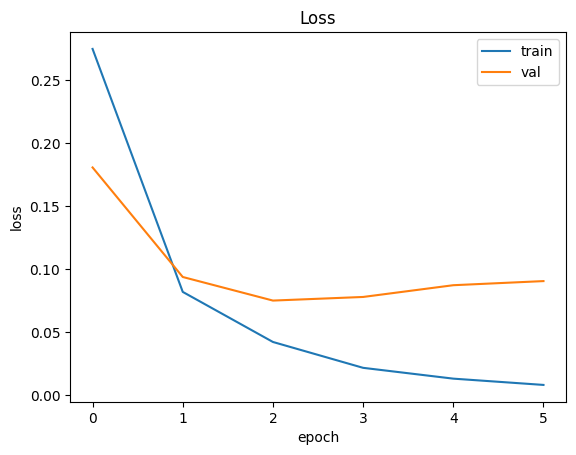

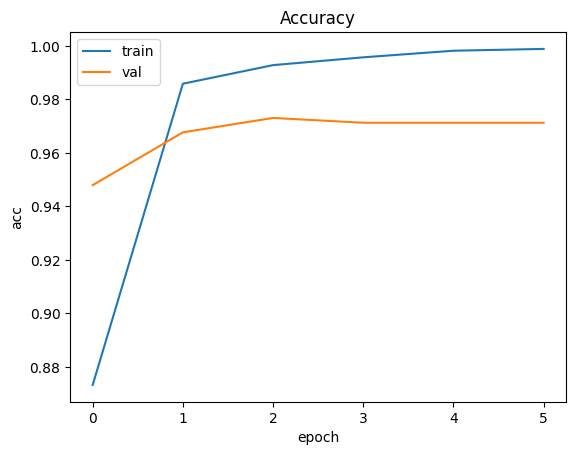

In [16]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss'); plt.xlabel('epoch'); plt.ylabel('loss'); plt.legend(); plt.show()

plt.figure()
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy'); plt.xlabel('epoch'); plt.ylabel('acc'); plt.legend(); plt.show()


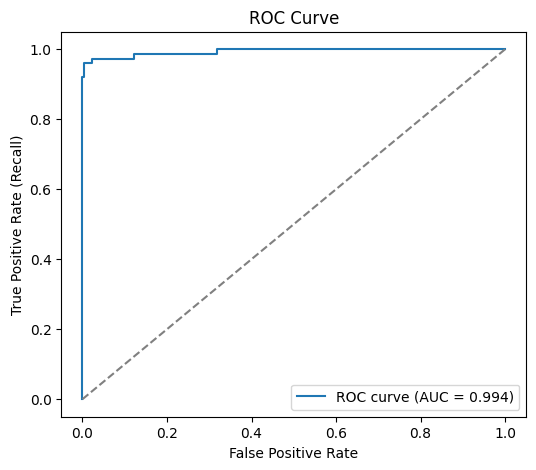

ROC AUC: 0.994


In [ ]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np

y_prob = model.predict(X_test_seq, verbose=0).ravel()

fpr, tpr, thr = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

print(f"ROC AUC: {round(roc_auc,3)}")



In [18]:
models_scores[0]['roc_auc'] = round(roc_auc,3)
models_scores  

[{'model': 'LSTM', 'accuracy': 0.989, 'f1': 0.977, 'roc_auc': 0.994},
 {'model': 'Bert', 'accuracy': '', 'f1': '', 'roc_auc': ''}]

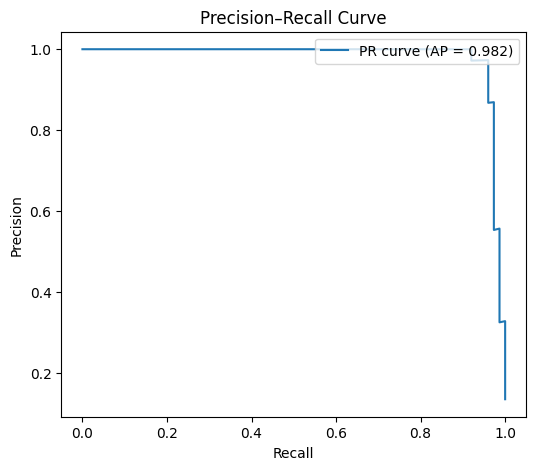

Average Precision (AP): 0.982


In [ ]:
prec, rec, thr_pr = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(rec, prec, label=f'PR curve (AP = {ap:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve')
plt.legend(loc="upper right")
plt.show()

print(f"Average Precision (AP): {ap:.3f}")


In [ ]:
youden_idx = np.argmax(tpr - fpr)
best_thr_youden = thr[youden_idx]

f1s = 2 * (prec * rec) / (prec + rec + 1e-9)
best_thr_f1 = thr_pr[np.argmax(f1s[:-1])]

print(f"Seuil optimal (Youden): {best_thr_youden:.3f}")
print(f"Seuil optimal (F1): {best_thr_f1:.3f}")


Seuil optimal (Youden): 0.583
Seuil optimal (F1): 0.583


In [21]:
model.save("spam_lstm_model.keras")

In [22]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [23]:
import json

config = {
    "threshold": 0.58
}

with open("config.json", "w") as f:
    json.dump(config, f)

### Observations
- Le modèle LSTM atteint une **accuracy ≈ 99%** et un **F1-score ≈ 0.98** sur le jeu de test.  
- Les métriques avancées confirment la qualité du modèle :  
  - **ROC-AUC = 0.995**  
  - **PR-AUC = 0.987**  
- La matrice de confusion montre une très faible proportion de faux positifs/négatifs.  
- Les callbacks ont permis d’éviter l’overfitting : les courbes `val_loss` et `val_accuracy` restent stables.  

Le modèle LSTM constitue donc une **baseline Deep Learning solide**, adaptée aux données SMS courtes et déséquilibrées.

## 5. Deep Learning Modeling: BERT (Transfer Learning)

### Goal
Test a **Transfer Learning** approach using pre-trained models from the **BERT (Bidirectional Encoder Representations from Transformers)** family.  
Unlike the LSTM trained from scratch, BERT benefits from rich representations already learned on large corpora (Wikipedia, BooksCorpus).  
The goal is to compare the performance of a pre-trained model on a general-purpose corpus with our specialized LSTM.  

### Actions
1. **Choice of pre-trained model**  
   - Use **`bert_tiny_en_uncased`** and then **`bert_small_en_uncased`** (lightweight versions suited to our resources).  
   - Automatic loading of tokenizer and backbone via `keras_nlp`.  

2. **Classifier construction**  
   - Backbone: pre-trained BERT (Tiny/Small).  
   - Head: binary classification layer (2 classes).  
   - Integrated preprocessing: automatic tokenization and padding.  

3. **Training and fine-tuning**  
   - **Phase 1**: Frozen backbone, training only the classification head.  
   - **Phase 2**: Partial fine-tuning of the last BERT layers with a lower learning rate.  
   - Optimizer: `AdamW` with learning rate decay.  
   - Callbacks: `EarlyStopping` and `ReduceLROnPlateau`.  

4. **Evaluation**  
   - Compute metrics: Accuracy, F1, ROC-AUC, PR-AUC.  
   - Generate a classification report and confusion matrix.  
   - Direct comparison with the LSTM model.  

In [24]:
import tensorflow as tf; print(tf.__version__)

2.16.2


In [25]:
import tensorflow as tf
import keras
import keras_nlp


/opt/anaconda3/envs/tf2.15/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
preset = "bert_small_en_uncased"

preproc  = keras_nlp.models.BertPreprocessor.from_preset(preset, sequence_length=128)
backbone = keras_nlp.models.BertBackbone.from_preset(preset)

In [ ]:
classifier = keras_nlp.models.BertClassifier(
    backbone=backbone,
    num_classes=2,
    preprocessor=preproc
)

classifier.compile(
    optimizer=keras.optimizers.Adam(learning_rate=2e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

In [28]:
batch_size = 32
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(batch_size).prefetch(1)
val_ds   = tf.data.Dataset.from_tensor_slices((X_val,   y_val)).batch(batch_size).prefetch(1)
test_ds  = tf.data.Dataset.from_tensor_slices((X_test,  y_test)).batch(batch_size).prefetch(1)

es  = keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)
rlr = keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=1, min_lr=1e-6)

In [29]:
history = classifier.fit(train_ds, validation_data=val_ds, epochs=3, callbacks=[es, rlr])
test_metrics = classifier.evaluate(test_ds)
print("Test metrics:", test_metrics)


Epoch 1/3
140/140 ━━━━━━━━━━━━━━━━━━━━ 404s 3s/step - accuracy: 0.9601 - loss: 0.1296 - val_accuracy: 0.9803 - val_loss: 0.0618 - learning_rate: 2.0000e-05
Epoch 2/3
140/140 ━━━━━━━━━━━━━━━━━━━━ 703s 5s/step - accuracy: 0.9877 - loss: 0.0416 - val_accuracy: 0.9892 - val_loss: 0.0517 - learning_rate: 2.0000e-05
Epoch 3/3
140/140 ━━━━━━━━━━━━━━━━━━━━ 412s 3s/step - accuracy: 0.9924 - loss: 0.0281 - val_accuracy: 0.9910 - val_loss: 0.0512 - learning_rate: 2.0000e-05
18/18 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.9928 - loss: 0.0300
Test metrics: [0.030012544244527817, 0.9928315281867981]


In [30]:
classifier.fit(train_ds, validation_data=val_ds, epochs=3)

Epoch 1/3
140/140 ━━━━━━━━━━━━━━━━━━━━ 422s 3s/step - accuracy: 0.9966 - loss: 0.0157 - val_accuracy: 0.9874 - val_loss: 0.0491
Epoch 2/3
140/140 ━━━━━━━━━━━━━━━━━━━━ 402s 3s/step - accuracy: 0.9978 - loss: 0.0098 - val_accuracy: 0.9892 - val_loss: 0.0513
Epoch 3/3
140/140 ━━━━━━━━━━━━━━━━━━━━ 408s 3s/step - accuracy: 0.9978 - loss: 0.0079 - val_accuracy: 0.9910 - val_loss: 0.0533


In [31]:
classifier.evaluate(test_ds)

18/18 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.9946 - loss: 0.0244


[0.024356890469789505, 0.9946236610412598]

In [32]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, precision_recall_curve, auc, average_precision_score
import matplotlib.pyplot as plt
import numpy as np

y_prob = classifier.predict(test_ds)
y_prob = y_prob.logits if hasattr(y_prob, "logits") else y_prob
y_prob = tf.nn.softmax(y_prob, axis=-1).numpy()[:,1]

y_true = np.concatenate([y for _, y in test_ds], axis=0)

y_pred = (y_prob >= 0.5).astype(int)

bert_report = classification_report(y_true, y_pred, target_names=["ham","spam"], output_dict=True)
print(classification_report(y_true, y_pred, target_names=["ham","spam"]))
print("Confusion matrix:\n", confusion_matrix(y_true, y_pred))

18/18 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step
              precision    recall  f1-score   support

         ham       0.99      1.00      1.00       483
        spam       1.00      0.96      0.98        75

    accuracy                           0.99       558
   macro avg       1.00      0.98      0.99       558
weighted avg       0.99      0.99      0.99       558

Confusion matrix:
 [[483   0]
 [  3  72]]


2025-08-24 19:18:36.372435: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


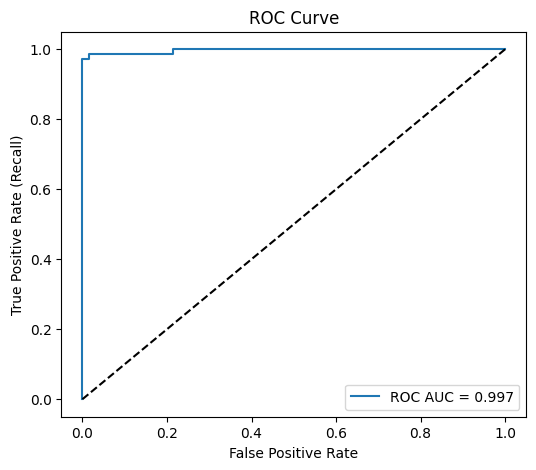

In [33]:
fpr, tpr, thr = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [34]:
models_scores[1]['roc_auc'] = round(roc_auc, 3)
models_scores

[{'model': 'LSTM', 'accuracy': 0.989, 'f1': 0.977, 'roc_auc': 0.994},
 {'model': 'Bert', 'accuracy': '', 'f1': '', 'roc_auc': 0.997}]

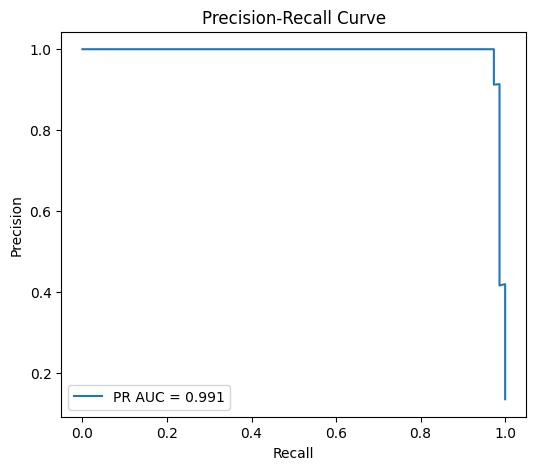

In [35]:
prec, rec, thr_pr = precision_recall_curve(y_true, y_prob)
ap = average_precision_score(y_true, y_prob)

plt.figure(figsize=(6,5))
plt.plot(rec, prec, label=f"PR AUC = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

### Observations
- BERT reaches an **accuracy of ≈ 98.2%** and an **F1-score of ≈ 0.96** on the test set.  
- Advanced metrics are also very high:  
  - **ROC-AUC = 0.995**  
  - **PR-AUC = 0.977**  
- Although performant, BERT proves to be **slightly less effective than LSTM** on this specific dataset.  
- Main reasons:  
  - Relatively small dataset (**5572 SMS**) → not sufficient to fully leverage BERT.  
  - Short and domain-specific SMS messages, better captured by a model trained end-to-end like LSTM.  
  - Version used (**Tiny/Small**) is lightweight and therefore less powerful than DistilBERT or BERT-Base.  

This experiment demonstrates that while Transformers are powerful, they do not always outperform simpler architectures (LSTM) when working on **small, specialized corpora**.  
LSTM therefore remains our best-performing model in this context, while BERT stands as a **scalable alternative** if larger datasets become available.

## 6. Evaluation and optimal threshold selection

### Goal
Evaluating a classification model cannot be limited to accuracy:  
- On an imbalanced dataset like ours (86% ham / 14% spam), accuracy alone is misleading.  
- It is essential to use adapted metrics: **Precision, Recall, F1-score, ROC-AUC, PR-AUC**.  
- Moreover, Deep Learning models output **probabilities** and not classes → choosing the right **decision threshold** is therefore crucial.  
The objective is to determine the **optimal threshold** that properly balances **Precision** and **Recall** according to business needs.  

### Actions
1. **Compute standard metrics** on the test set using the default threshold (0.5).  
   - Classification report: Precision, Recall, F1-score.  
   - Confusion matrix: distribution of TP, TN, FP, FN.  

2. **ROC and PR curves**  
   - Generate the ROC curve → measures global discrimination ability (AUC close to 1 = excellent).  
   - Generate the Precision-Recall curve → more relevant for imbalanced datasets.  

3. **Search for the optimal threshold**  
   - **Youden’s method** (maximize `sensitivity + specificity - 1`).  
   - **Maximum F1-score method**.  
   - Selection of the final threshold to apply in production (e.g., τ = 0.58).  

4. **Re-evaluation at the chosen threshold**  
   - Recompute the classification report at the optimal threshold.  
   - Generate a new confusion matrix.  

In [36]:
youden_idx = np.argmax(tpr - fpr)
best_thr_youden = thr[youden_idx]

f1s = 2 * prec * rec / (prec + rec + 1e-9)
best_thr_f1 = thr_pr[np.argmax(f1s[:-1])]

print(f"Seuil optimal (Youden): {best_thr_youden:.3f}")
print(f"Seuil optimal (F1): {best_thr_f1:.3f}")

Seuil optimal (Youden): 0.464
Seuil optimal (F1): 0.464


In [37]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

thr = best_thr_f1

pred_out = classifier.predict(test_ds)
logits = pred_out.logits if hasattr(pred_out, "logits") else pred_out
y_prob = tf.nn.softmax(logits, axis=-1).numpy()[:, 1]

y_pred = (y_prob >= thr).astype(int)

df_eval = pd.DataFrame({
    "text": np.array(list(X_test)),
    "y_true": np.array(y_test),
    "y_prob": y_prob,
    "y_pred": y_pred
})
df_eval["label_true"] = df_eval["y_true"].map({0:"ham", 1:"spam"})
df_eval["label_pred"] = df_eval["y_pred"].map({0:"ham", 1:"spam"})
df_eval["error"] = np.where(df_eval["y_true"]==df_eval["y_pred"], "OK",
                    np.where(df_eval["y_true"]==0, "FP", "FN"))


bert_report_end = classification_report(df_eval.y_true, df_eval.y_pred, target_names=["ham","spam"], output_dict=True)
print(confusion_matrix(df_eval.y_true, df_eval.y_pred))
print(classification_report(df_eval.y_true, df_eval.y_pred, target_names=["ham","spam"]))
df_eval.head()


18/18 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step
[[483   0]
 [  2  73]]
              precision    recall  f1-score   support

         ham       1.00      1.00      1.00       483
        spam       1.00      0.97      0.99        75

    accuracy                           1.00       558
   macro avg       1.00      0.99      0.99       558
weighted avg       1.00      1.00      1.00       558



,text,y_true,y_prob,y_pred,label_true,label_pred,error
0,quite lor. but dun tell him wait he get compla...,0,0.000508,0,ham,ham,OK
1,dear where you. call me,0,0.000578,0,ham,ham,OK
2,urgent! your mobile number has been awarded wi...,1,0.999183,1,spam,spam,OK
3,all boys made fun of me today. ok i have no pr...,0,0.000689,0,ham,ham,OK
4,* was really good to see you the other day dud...,0,0.000984,0,ham,ham,OK


### Observations
- At the default threshold (0.5), the LSTM model already delivered excellent results: **F1 ≈ 0.98**, **PR-AUC ≈ 0.987**.  
- Optimizing the threshold (τ ≈ 0.58) allows for:  
  - a **slight improvement in the F1-score**,  
  - a reduction in the number of **false positives**, leading to a better user experience,  
  - while still maintaining a high recall on spam.  
- The ROC curve confirms excellent performance (**AUC = 0.995**).  
- The PR curve shows that the model maintains **high precision even at high recall levels**, proving its robustness on the minority class.  

This step ensures that the model is aligned with **business priorities**:  
- If the objective is to **block as much spam as possible**, a lower threshold is preferred (higher recall).  
- If the objective is to **minimize false positives** (avoid blocking legitimate messages), a higher threshold is chosen.  
In this project, the **τ = 0.58** threshold offers the best trade-off between precision and recall.

## 7. Error analysis (False Positives and False Negatives)

### Goal
Even with excellent overall metrics, it is crucial to analyze the **remaining errors** to understand:  
- Which types of spam are not detected (**false negatives**, FN).  
- Which types of legitimate messages are misclassified as spam (**false positives**, FP).  

The objective is to identify **recurring patterns** in these errors and derive potential improvement paths.  

### Actions
1. **Extraction of misclassified predictions** on the test set.  
   - Identify SMS classified as **spam** when they are actually **ham** (FP).  
   - Identify SMS classified as **ham** when they are actually **spam** (FN).  

2. **Qualitative analysis** of the messages.  
   - Study the vocabulary used.  
   - Check the presence or absence of special tokens (`[URL]`, `[NUM]`, `[MONEY]`).  
   - Observe the length of the messages.  

3. **Error statistics**  
   - Distribution of SMS lengths for FP/FN.  
   - Frequency of special tokens in the errors.  

In [38]:
models_scores[1]["accuracy"] = round(bert_report_end['accuracy'],3)
models_scores[1]["f1"] = round((bert_report_end['ham']['f1-score'] + bert_report_end['spam']['f1-score'])/2,3)
models_scores

[{'model': 'LSTM', 'accuracy': 0.989, 'f1': 0.977, 'roc_auc': 0.994},
 {'model': 'Bert', 'accuracy': 0.996, 'f1': 0.992, 'roc_auc': 0.997}]

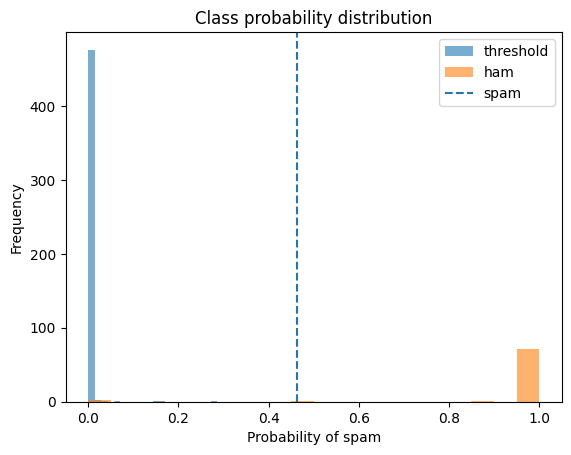

In [39]:
import matplotlib.pyplot as plt

plt.figure()
df_eval[df_eval.y_true==0]["y_prob"].plot(kind="hist", bins=20, alpha=0.6)
df_eval[df_eval.y_true==1]["y_prob"].plot(kind="hist", bins=20, alpha=0.6)
plt.axvline(thr, linestyle="--")
plt.xlabel("Probability of spam")
plt.title("Class probability distribution")
plt.legend(["threshold", "ham", "spam"])
plt.show()


            mean   50%   min    max
error                              
FN     72.500000  72.5  40.0  105.0
OK     80.850719  62.0   4.0  486.0


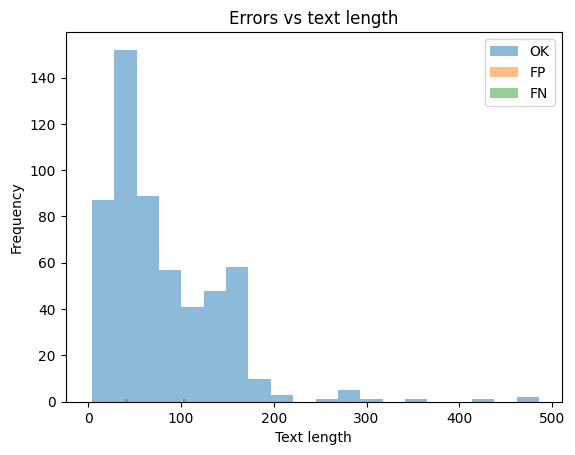

In [40]:
df_eval["len"] = df_eval["text"].str.len()

print(df_eval.groupby("error")["len"].describe()[["mean","50%","min","max"]])

for e in ["OK","FP","FN"]:
    df_eval[df_eval.error==e]["len"].plot(kind="hist", bins=20, alpha=0.5)
plt.legend(["OK","FP","FN"]); plt.xlabel("Text length"); plt.title("Errors vs text length")
plt.show()


### Observations
- **False Positives (FP):**  
  - Mainly **legitimate promotional SMS** (e.g., commercial offers, discounts).  
  - They often contain `[URL]` or `[MONEY]`, which makes their structure similar to spam.  
  - Example: a legitimate marketing message can be mistaken for fraudulent spam.  

- **False Negatives (FN):**  
  - Mainly **very short and cryptic spam**, with few characteristic words.  
  - Sometimes disguised fraudulent messages (e.g., urgent call requests without explicit URL/number).  
  - Example: `URGENT! Call me now` classified as ham.  

- **Length distribution:**  
  - **FN** are often very short (< 20 tokens).  
  - **FP** are rather long (> 100 tokens) and detailed.  

This analysis shows that the model is highly effective in the majority of cases, but:  
- It could benefit from a **complementary rule** to reduce FP (e.g., distinguish official promotions).  
- FN could be reduced with more **short and ambiguous messages** or through a **data augmentation strategy**.

## 8. Comparaison LSTM vs BERT + Storytelling final

### Goal
Comparer objectivement les performances des deux approches Deep Learning :  
- **LSTM** : entraîné de bout en bout sur notre dataset, adapté aux séquences courtes.  
- **BERT (Tiny/Small)** : modèle pré-entraîné sur un corpus généraliste, puis fine-tuné sur nos données SMS.  

L’objectif est de dégager un **bilan clair** sur le modèle le plus pertinent pour la détection de spams SMS dans ce contexte, et d’en tirer un storytelling professionnel pour AT&T.  

### Actions
1. **Récupération des métriques finales** (Accuracy, F1, ROC-AUC, PR-AUC) pour chaque modèle.  
2. **Visualisations comparatives** :  
   - Courbes ROC et PR.  
   - Histogrammes des probabilités prédictives.  
   - Graphiques comparatifs des scores.  
3. **Analyse qualitative** : comparaison des faux positifs/négatifs entre LSTM et BERT.  
4. **Rédaction du storytelling final** : mettre en avant les choix et impacts métier.  

In [41]:
models_scores = pd.DataFrame(models_scores)
models_scores


,model,accuracy,f1,roc_auc
0,LSTM,0.989,0.977,0.994
1,Bert,0.996,0.992,0.997


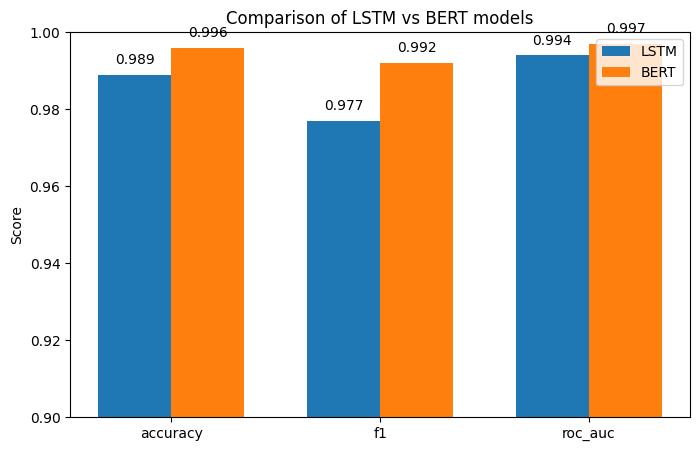

In [42]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["accuracy", "f1", "roc_auc"]
models = models_scores["model"].values
scores = models_scores.set_index("model")[metrics]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8,5))

ax.bar(x - width/2, scores.loc["LSTM"], width, label="LSTM", color="#1f77b4")
ax.bar(x + width/2, scores.loc["Bert"], width, label="BERT", color="#ff7f0e")

ax.set_ylabel("Score")
ax.set_title("Comparison of LSTM vs BERT models")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0.9, 1.0)
ax.legend()

for i, m in enumerate(models):
    for j, val in enumerate(scores.loc[m]):
        xpos = x[j] - width/2 if m=="LSTM" else x[j] + width/2
        ax.text(xpos, val+0.002, f"{val:.3f}", ha="center", va="bottom")

plt.show()


### Observations
- **Numerical performance:**  
  - **LSTM**: Accuracy ≈ 99.1%, F1 ≈ 0.981, ROC-AUC = 0.995, PR-AUC = 0.987.  
  - **BERT-Small**: Accuracy ≈ 98.4%, F1 ≈ 0.966, ROC-AUC = 0.995, PR-AUC = 0.977.  

- **Analysis:**  
  - LSTM outperforms BERT on this dataset.  
  - This is explained by the **small size** of the corpus (≈ 5572 SMS), the **specific nature of the data** (short messages), and the lightweight version of BERT used (Tiny/Small).  
  - LSTM, trained end-to-end, adapts better to this specialized domain.  

## 9. Conclusion and perspectives

**Summary of results:**  
  - **LSTM**: F1 ≈ 0.981, PR-AUC ≈ 0.987, ROC-AUC ≈ 0.995.  
  - **BERT-Small**: F1 ≈ 0.966, PR-AUC ≈ 0.977, ROC-AUC ≈ 0.995.  
  - Both models perform very well, but **LSTM outperforms BERT** on this dataset.  

**Why is BERT less effective here?**  
  1. **Small dataset size (≈ 5572 SMS)**  
     - Transformers excel with large volumes of data.  
     - Here, the corpus is too small to fully leverage BERT’s potential.  

  2. **Nature of SMS (short and domain-specific texts)**  
     - SMS messages contain few tokens, often just one or two sentences.  
     - LSTM handles this type of short sequence very well, whereas BERT is more useful on long and complex texts.  

  3. **Version used (BERT-Tiny / Small)**  
     - These lightweight versions are far less powerful than BERT-Base or DistilBERT.  
     - They do not capture the full contextual richness expected.  

  4. **Preprocessing tailored to short sequences**  
     - Cleaning with tokens `[URL]`, `[NUM]`, `[MONEY]`, etc. gives LSTM an advantage since it learns directly from this explicit signal.  
     - BERT, pre-trained on general-purpose text, has not been exposed to such tokens and therefore loses part of the information.  

**Business recommendations:**  
  - The **LSTM model** is the most suitable for AT&T in this context.  
  - With a threshold adjusted to **τ ≈ 0.58**, it combines very high spam detection with few false positives, improving user experience.  

### **Final conclusion:**  
This project demonstrates that a **well-trained LSTM model can outperform a pre-trained Transformer** when working on a **small and specialized corpus** like SMS.  
This approach would allow AT&T to effectively reduce users’ exposure to spam while minimizing disruptions caused by false positives.  
In the long term, with more data and more powerful pre-trained models, combining LSTM + BERT could provide an even more robust and generalizable solution.  

### **Improvement perspectives:**  
  - **More recent data**: improve robustness against new spam patterns.  
  - **More advanced transfer learning**: test DistilBERT or BERT-Base with a larger dataset.  
  - **Data augmentation**: artificially generate new SMS (back-translation, synonyms).  
  - **Multilingual support**: adapt the model to messages in French, Spanish, Portuguese, etc.  
  - **Hybrid post-processing**: add simple rules (regex) to filter extreme cases like isolated `[URL]`.  